In [2]:
import os
import math
import glob
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import GPUtil

/aul/homes/hsale014/myenvpy3-11/lib64/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def setup_device(device_type: str):
    if device_type == "GPU":
        try:
            return select_free_gpu(max_memory_usage=0.5)
        except Exception as e:
            print(f"Error selecting GPU: {e}")
            print("No free GPU available. Selecting CPU for processing.")
            return torch.device("cpu")
    return torch.device("cpu")

def select_free_gpu(max_memory_usage=0.5, priority="memory"):
    """
    Select a GPU whose memory usage is less than `max_memory_usage`.
    Among those, either pick the GPU with the lowest load (priority="load")
    or the one with the lowest memory usage (priority="memory").
    If no GPU satisfies the memory criterion, pick the GPU with the smallest
    (memoryUtil, load) among all GPUs.
    """
    devices = GPUtil.getGPUs()
    # Filter out GPUs that exceed the memory threshold
    available_gpus = [i for i in range(len(devices)) if devices[i].memoryUtil < max_memory_usage]

    if not available_gpus:
        print(f"No available GPU with memory usage < {max_memory_usage*100:.0f}%.")
        # Fallback: pick GPU with smallest memory usage, then load
        selected_gpu = sorted(devices, key=lambda x: (x.memoryUtil, x.load))[0].id
    else:
        print(f"GPUs below {max_memory_usage*100:.0f}% memory usage: {available_gpus}")
        if priority == "memory":
            # Pick the GPU with the *lowest memory usage* among the filtered set
            mem_util_values = [devices[i].memoryUtil for i in available_gpus]
            min_mem = min(mem_util_values)
            min_mem_index = mem_util_values.index(min_mem)
            selected_gpu = available_gpus[min_mem_index]
        else:
            # Priority="load": pick the GPU with the *lowest load*
            gpu_loads = [devices[i].load for i in available_gpus]
            min_load = min(gpu_loads)
            min_load_index = gpu_loads.index(min_load)
            selected_gpu = available_gpus[min_load_index]
    
    chosen = devices[selected_gpu]
    print(f"Selected GPU: {selected_gpu} "
          f"(memory={chosen.memoryUtil*100:.1f}%, "
          f"load={chosen.load*100:.1f}%)")
    
    return torch.device(f"cuda:{selected_gpu}" if torch.cuda.is_available() else "cpu")

In [4]:
device = setup_device("GPU")

GPUs below 50% memory usage: [1, 2, 3, 4, 5, 6, 7]
Selected GPU: 1 (memory=0.0%, load=0.0%)


In [5]:
############################################
# Dataset Class
############################################
class StockImageDataset(Dataset):
    def __init__(self, root_dir, train=True, transform=None, train_ratio=0.9):
        self.root_dir = root_dir
        self.transform = transform
        # Get sorted list of images
        self.image_paths = sorted(glob.glob(os.path.join(root_dir, 'stock_*.png')))
        total_images = len(self.image_paths)
        train_count = int(total_images * train_ratio)
        if train:
            self.image_paths = self.image_paths[:train_count]
        else:
            self.image_paths = self.image_paths[train_count:]
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        path = self.image_paths[idx]
        img = Image.open(path).convert('RGB')  # RGB image
        if self.transform is not None:
            img = self.transform(img)
        # img: (C=3, H, W)
        return img


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim=None):
        super().__init__()
        # print(f"\n=== Block Initialization ===")
        # print(f"Input channels: {in_ch}")
        # print(f"Output channels: {out_ch}")
        # print(f"Time embedding dim: {time_emb_dim}")
        
        self.in_ch = in_ch
        self.out_ch = out_ch
        self.time_mlp = nn.Linear(time_emb_dim, out_ch) if time_emb_dim else None
        
        # print(f"Creating conv1 with in_ch={in_ch}, out_ch={out_ch}")
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_ch)
        # print(f"Creating conv2 with in_ch={out_ch}, out_ch={out_ch}")
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm2 = nn.GroupNorm(8, out_ch)
        # if in_ch != out_ch:
        #     print(f"Creating skip connection conv with in_ch={in_ch}, out_ch={out_ch}")
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        # print("=== Block Initialization Complete ===\n")

    def forward(self, x, time_emb=None):
        # print(f"\n=== Block Forward Pass ===")
        # print(f"Input tensor shape: {x.shape}")
        # print(f"Block's configured in_ch: {self.in_ch}")
        # print(f"Block's configured out_ch: {self.out_ch}")
        
        if x.shape[1] != self.in_ch:
            print(f"WARNING: Channel mismatch!")
            print(f"Expected {self.in_ch} channels, got {x.shape[1]} channels")
            
        h = self.conv1(x)
        # print(f"After conv1 shape: {h.shape}")
        h = self.norm1(h)
        h = F.silu(h)
        
        if self.time_mlp and time_emb is not None:
            time_emb = self.time_mlp(F.silu(time_emb))
            # print(f"Time embedding shape: {time_emb.shape}")
            h = h + time_emb[..., None, None]
            
        h = self.conv2(h)
        # print(f"After conv2 shape: {h.shape}")
        h = self.norm2(h)
        h = F.silu(h)
        
        skip_out = self.skip(x)
        # print(f"Skip connection output shape: {skip_out.shape}")
        
        out = h + skip_out
        # print(f"Final output shape: {out.shape}")
        # print("=== Block Forward Pass Complete ===\n")
        return out

class AttentionBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        # print(f"\nInitializing AttentionBlock with channels={channels}")
        self.channels = channels
        self.norm = nn.GroupNorm(8, channels)
        self.qkv = nn.Conv2d(channels, channels * 3, 1)
        self.proj = nn.Conv2d(channels, channels, 1)

    def forward(self, x):
        # print(f"\nAttentionBlock forward - Input shape: {x.shape}")
        B, C, H, W = x.shape
        qkv = self.qkv(self.norm(x))
        q, k, v = qkv.chunk(3, dim=1)
        
        scale = 1 / math.sqrt(math.sqrt(C))
        attn = torch.einsum('bci,bcj->bij', q.view(B, C, -1) * scale, k.view(B, C, -1) * scale)
        attn = attn.softmax(dim=-1)
        
        h = torch.einsum('bij,bcj->bci', attn, v.view(B, C, -1))
        h = h.view(B, C, H, W)
        out = self.proj(h) + x
        # print(f"AttentionBlock output shape: {out.shape}")
        return out

class UNet(nn.Module):
    def __init__(
        self,
        in_channels=3,
        out_channels=3,
        time_emb_dim=256,
        base_channels=64,
        channel_mults=(1, 2, 4, 8),
        attention_resolutions=(8, 16),
    ):
        super().__init__()
        # print(f"\nInitializing UNet with:")
        # print(f"in_channels={in_channels}, out_channels={out_channels}")
        # print(f"base_channels={base_channels}")
        # print(f"channel_mults={channel_mults}")
        
        # Time embedding and initial conv remain the same
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim * 4),
            nn.SiLU(),
            nn.Linear(time_emb_dim * 4, time_emb_dim)
        )
        
        self.init_conv = nn.Conv2d(in_channels, base_channels, 3, padding=1)
        
        # Downsampling path
        self.downs = nn.ModuleList([])
        channels = []  # Track channels for skip connections
        in_ch = base_channels
        
        # print("\nDownsampling path:")
        for level, mult in enumerate(channel_mults):
            out_ch = base_channels * mult
            # print(f"\nLevel {level} - in_ch: {in_ch}, out_ch: {out_ch}")
            
            for _ in range(2):
                self.downs.append(Block(in_ch, out_ch, time_emb_dim))
                channels.append(out_ch)  # Keep track of channels for skip connections
                if out_ch in attention_resolutions:
                    self.downs.append(AttentionBlock(out_ch))
                in_ch = out_ch
            
            if level != len(channel_mults) - 1:
                self.downs.append(nn.Conv2d(out_ch, out_ch, 3, stride=2, padding=1))
                # Removed channels.append(out_ch) from here
        
        # Middle
        mid_channels = base_channels * channel_mults[-1]
        # print(f"\nMiddle - channels: {mid_channels}")
        self.middle = nn.ModuleList([
            Block(mid_channels, mid_channels, time_emb_dim),
            AttentionBlock(mid_channels),
            Block(mid_channels, mid_channels, time_emb_dim)
        ])
        
        # Upsampling
        self.ups = nn.ModuleList([])
        # print("\nUpsampling path:")
        channels = channels[::-1]  # Reverse channels for skip connections
        in_ch = mid_channels
        
        for level, mult in reversed(list(enumerate(channel_mults))):
            out_ch = base_channels * mult
            # print(f"\nLevel {level} - out_ch: {out_ch}")
            
            # First block: input channels = current + skip
            skip_ch = channels.pop(0)
            up_in_ch = in_ch + skip_ch
            # print(f"First block - in_ch: {up_in_ch} ({in_ch} + {skip_ch}), out_ch: {out_ch}")
            self.ups.append(Block(up_in_ch, out_ch, time_emb_dim))
            
            if out_ch in attention_resolutions:
                self.ups.append(AttentionBlock(out_ch))
            
            # Second block: input channels = current + skip
            skip_ch = channels.pop(0)
            up_in_ch = out_ch + skip_ch
            # print(f"Second block - in_ch: {up_in_ch} ({out_ch} + {skip_ch}), out_ch: {out_ch}")
            self.ups.append(Block(up_in_ch, out_ch, time_emb_dim))
            
            if out_ch in attention_resolutions:
                self.ups.append(AttentionBlock(out_ch))
            
            if level != 0:
                self.ups.append(nn.ConvTranspose2d(out_ch, out_ch, 4, stride=2, padding=1))
            
            in_ch = out_ch
        
        # Final block
        final_skip_ch = channels[0] if channels else base_channels
        # print(f"\nFinal block - in_ch: {in_ch + final_skip_ch} ({in_ch} + {final_skip_ch}), out_ch: {base_channels}")
        self.final = nn.Sequential(
            Block(in_ch + final_skip_ch, base_channels, time_emb_dim),
            nn.Conv2d(base_channels, out_channels, 3, padding=1)
        )
        
        # print("\nInitialization complete")

    def forward(self, x, time):
        # print("\n=== Starting UNet Forward Pass ===")
        
        # Time embedding
        t = self.time_mlp(time)
        # print(f"Time embedding shape: {t.shape}")
        
        # Initial conv
        h = self.init_conv(x)
        # print(f"After initial conv: {h.shape}")
        
        # Store skip connections
        skips = []
        first_skip = None
        
        # Downsampling
        # print("\n=== Starting Downsampling Path ===")
        skips = []
        for i, layer in enumerate(self.downs):
            # print(f"\n--- Downsampling Layer {i} ---")
            # print(f"Current feature map shape: {h.shape}")
            
            if isinstance(layer, Block):
                h = layer(h, t)
                if first_skip is None:
                    first_skip = h
     
                skips.append(h)
                # print(f"Stored skip connection with shape: {h.shape}")
                
            elif isinstance(layer, nn.Conv2d):
                # print("Processing downsampling conv")
                # print(f"Conv weight shape: {layer.weight.shape}")
                h = layer(h)
                # print(f"After downsampling shape: {h.shape}")
        
        # Middle
        # print("\n=== Middle Blocks ===")
        for i, layer in enumerate(self.middle):
            if isinstance(layer, Block):
                # print(f"\nMiddle Block {i}")
                h = layer(h, t)
            else:
                # print(f"\nMiddle Attention {i}")
                h = layer(h)
            # print(f"After middle block {i}, shape: {h.shape}")
        
        # Upsampling
        # Upsampling
        # print("\n=== Starting Upsampling Path ===")
        for i, layer in enumerate(self.ups):
            # print(f"\n--- Upsampling Layer {i} ---")
            # print(f"Current feature map shape: {h.shape}")
            
            if isinstance(layer, nn.ConvTranspose2d):
                # print("Processing ConvTranspose2d layer")
                # print(f"Layer weight shape: {layer.weight.shape}")
                h = layer(h)
                # print(f"After upsampling shape: {h.shape}")
            
            elif isinstance(layer, Block):
                # print("Processing Block layer")
                if len(skips) > 0:
                    skip = skips.pop()
                    # print(f"Skip connection shape: {skip.shape}")
                    # print(f"Current feature map shape before concat: {h.shape}")
                    h = torch.cat([h, skip], dim=1)
                    # print(f"After concatenation shape: {h.shape}")
                    # print(f"Block's expected input channels: {layer.in_ch}")
                h = layer(h, t)
                # print(f"After block processing shape: {h.shape}")
            
            elif isinstance(layer, AttentionBlock):
                # print("Processing AttentionBlock layer")
                # print(f"Input shape to attention: {h.shape}")
                h = layer(h)
                # print(f"After attention shape: {h.shape}")

        # Final
        # print("\n=== Final Processing ===")
        # print(f"Before final processing, shape: {h.shape}")
        # if len(skips) > 0:
        # skip = skips.pop()
        h = torch.cat([h, first_skip], dim=1)
        # print(f"After final concatenation: {h.shape}")
        h = self.final(h)
        # print(f"Final output shape: {h.shape}")
        
        return h

class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings


In [7]:
model = UNet(
    in_channels=3,
    out_channels=3,
    base_channels=64,
    channel_mults=(1, 2, 4, 8),
    attention_resolutions=(8, 16),
    time_emb_dim=256
)

print("\nTesting model:")
batch_size = 4
x = torch.randn(batch_size, 3, 224, 224)
t = torch.randint(0, 1000, (batch_size,))
output = model(x, t)


Testing model:


Using device: cuda:1
Batch shape: torch.Size([4, 3, 224, 224])


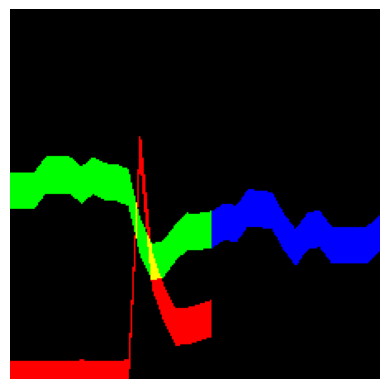

In [8]:
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Setup device

print(f"Using device: {device}")

# Define parameters
batch_size = 4
image_size = 224
n_timesteps = 1000  # Number of diffusion steps

# Load your dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Use your existing dataset class
train_dataset = StockImageDataset('stock_images', train=True, transform=transform)
test_dataset = StockImageDataset('stock_images', train=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Let's verify the data loading
sample_batch = next(iter(train_loader))
print(f"Batch shape: {sample_batch.shape}")

# Visualize one sample
def show_sample(img_tensor):
    img = img_tensor.permute(1, 2, 0).numpy()
    # print(img[:,:,2])
    img = (img + 1) / 2.0  # Denormalize
    plt.imshow(img)
    plt.axis('off')
    # plt.show()

show_sample(sample_batch[0])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


cuda:1
cuda:1
cuda:1
cuda:1
cuda:1
tensor([[-1.0001, -0.9999, -1.0114,  ..., -0.9919, -0.9860, -0.9963],
        [-0.9992, -1.0006, -0.9933,  ..., -0.9852, -0.9967, -1.0104],
        [-1.0100, -0.9920, -0.9946,  ..., -0.9783, -1.0124, -0.9943],
        ...,
        [-0.9940, -0.9931, -1.0166,  ..., -1.0007, -1.0131, -0.9976],
        [-0.9839, -1.0017, -1.0104,  ..., -1.0082, -0.9807, -1.0078],
        [-1.0059, -1.0085, -1.0080,  ..., -0.9802, -1.0048, -1.0007]])
cuda:1
cuda:1
cuda:1
cuda:1
cuda:1
tensor([[-1.1380, -1.2714, -0.7183,  ..., -0.7876, -0.3107, -1.1422],
        [-1.2916, -0.7105, -1.1518,  ..., -0.5254, -0.6891, -1.0910],
        [-1.3266, -1.2058, -0.4690,  ...,  0.1890, -1.2437, -1.3801],
        ...,
        [-1.7934, -1.3898, -0.2741,  ..., -0.5517, -0.4963, -2.1484],
        [-0.9965, -0.7690, -1.5772,  ..., -0.4239,  0.0230, -1.1820],
        [ 0.1598, -1.3826, -1.6530,  ..., -1.4265, -1.2120, -0.9187]])
cuda:1
cuda:1
cuda:1
cuda:1
cuda:1
tensor([[-1.5015,  0.8164, 

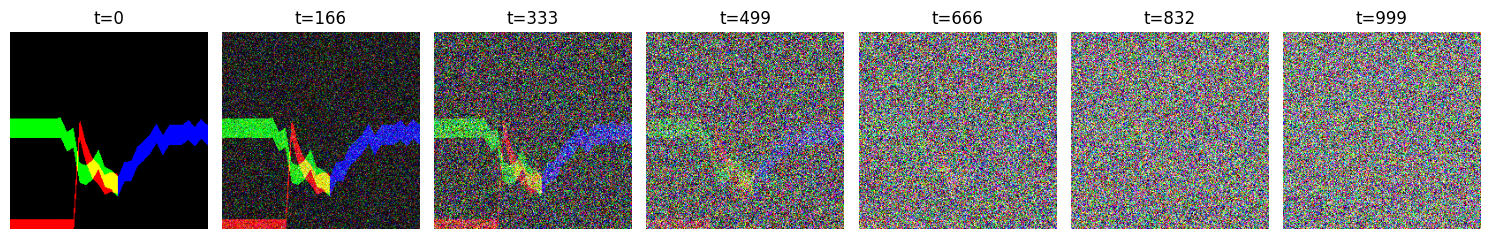

In [9]:
# Set up the noise schedule (beta schedule)
beta_start = 0.0001
beta_end = 0.02
betas = torch.linspace(beta_start, beta_end, n_timesteps)
alphas = 1 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

# Calculations for diffusion q(x_t | x_{t-1})
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)

# Move all tensors to device
betas = betas.to(device)
alphas = alphas.to(device)
alphas_cumprod = alphas_cumprod.to(device)
alphas_cumprod_prev = alphas_cumprod_prev.to(device)
sqrt_recip_alphas = sqrt_recip_alphas.to(device)
sqrt_alphas_cumprod = sqrt_alphas_cumprod.to(device)
sqrt_one_minus_alphas_cumprod = sqrt_one_minus_alphas_cumprod.to(device)

# Forward diffusion process
def q_sample(x_start, t, noise=None, device='cpu'):
    if noise is None:
        noise = torch.randn_like(x_start)
    
    sqrt_alphas_cumprod_t = extract(sqrt_alphas_cumprod, t, x_start.shape).to(device)
    sqrt_one_minus_alphas_cumprod_t = extract(sqrt_one_minus_alphas_cumprod, t, x_start.shape).to(device)
    #print all devices
    print(device)
    print(sqrt_alphas_cumprod_t.device)
    print(sqrt_one_minus_alphas_cumprod_t.device)
    print(x_start.device)
    print(noise.device)
    
    return sqrt_alphas_cumprod_t * x_start + sqrt_one_minus_alphas_cumprod_t * noise

# Helper function to extract appropriate timestep values
def extract(a, t, x_shape):
    batch_size = t.shape[0]
    out = a.gather(-1, t).float()
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1)))

# Test the forward process
# Get a sample batch
sample_batch = next(iter(train_loader)).to(device)

# Create a visualization of the forward process
plt.figure(figsize=(15, 5))
n_examples = 7
timesteps = torch.linspace(0, n_timesteps-1, n_examples).long()

for idx, t in enumerate(timesteps):
    t = t.unsqueeze(0).to(device)
    noised_image = q_sample(sample_batch[0:1], t, device=device)
    noised_image = noised_image.cpu().squeeze()
    print(noised_image[2])
    
    plt.subplot(1, n_examples, idx+1)
    show_sample(noised_image)
    plt.title(f't={t.item()}')

plt.tight_layout()
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


cuda:1
cuda:1
cuda:1
cuda:1
cuda:1
torch.Size([3, 224, 224])
cuda:1
cuda:1
cuda:1
cuda:1
cuda:1
torch.Size([3, 224, 224])
cuda:1
cuda:1
cuda:1
cuda:1
cuda:1
torch.Size([3, 224, 224])
cuda:1
cuda:1
cuda:1
cuda:1
cuda:1
torch.Size([3, 224, 224])
cuda:1
cuda:1
cuda:1
cuda:1
cuda:1
torch.Size([3, 224, 224])
cuda:1
cuda:1
cuda:1
cuda:1
cuda:1
torch.Size([3, 224, 224])
cuda:1
cuda:1
cuda:1
cuda:1
cuda:1
torch.Size([3, 224, 224])


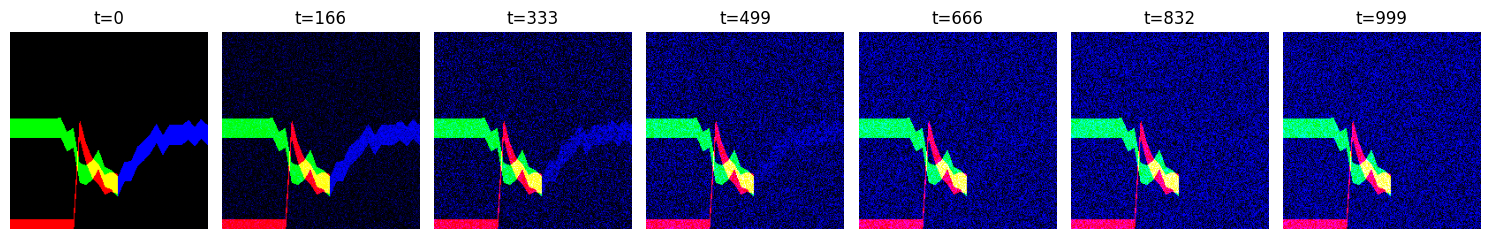

In [10]:
# Important: For your specific case, we want to only add noise to the third channel
# Let's modify the forward process to keep the first two channels intact
def q_sample_conditional(x_start, t, noise=None, device='cpu'):
    if noise is None:
        noise = torch.randn_like(x_start)
    
    # Only add noise to the third channel (index 2)
    noised = q_sample(x_start[:, 2:3], t, noise[:, 2:3], device)
    return torch.cat([x_start[:, :2], noised], dim=1)

# Test the conditional forward process
plt.figure(figsize=(15, 5))
for idx, t in enumerate(timesteps):
    t = t.unsqueeze(0).to(device)
    noised_image = q_sample_conditional(sample_batch[0:1], t, device=device)
    noised_image = noised_image.cpu().squeeze()
    # print the blue channel for me
    print(noised_image.shape)
    # print(noised_image[])
    
    plt.subplot(1, n_examples, idx+1)
    show_sample(noised_image)
    plt.title(f't={t.item()}')

plt.tight_layout()
plt.show()

In [11]:
def q_sample_conditional(x_start, t, noise=None, device='cpu'):
    if noise is None:
        noise = torch.randn_like(x_start[:, 2:3]).to(device)
    
    # Keep first two channels unchanged
    unchanged_channels = x_start[:, :2]
    
    # Add noise only to third channel
    print("device in q_sample_condition",device)
    noised_channel = q_sample(x_start[:, 2:3], t, noise, device)
    
    # Concatenate back all three channels
    result = torch.cat([unchanged_channels, noised_channel], dim=1)
    
    assert result.shape[1] == 3, f"Expected 3 channels, got {result.shape[1]}"
    return result.to(device)

In [12]:
# device = setup_device('GPU')

# Move model to device
model = model.to(device)

# Setup optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)



# Loss function will be MSE
def get_loss(model_output, noise):
    return F.mse_loss(model_output, noise)

# Training loop parameters
n_epochs = 10
save_every = 1  # Save model every 10 epochs

# Lists to store losses
train_losses = []

for epoch in range(n_epochs):
    model.train()
    epoch_losses = []
    
    for batch in train_loader:
        # Move batch to device
        batch = batch.to(device)
        # print("Original batch shape:", batch.shape)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Sample random timesteps
        t = torch.randint(0, n_timesteps, (batch.size(0),), device=device).long()
        
        # Generate random noise only for the third channel
        noise = torch.randn_like(batch[:, 2:3]).to(device)
        
        # Get noisy image (only third channel is noised)
        noised_batch = q_sample_conditional(batch, t, noise, device)
        # print(noised_batch.shape)
        # Predict noise
        predicted_noise = model(noised_batch, t).to(device)
        # print(predicted_noise.shape)
        predicted_noise = model(noised_batch, t)[:, 2:3]  # Only take third channel output
        
        # Calculate loss only on third channel
        loss = get_loss(predicted_noise, noise)
        # print(loss)
        
        # Backpropagate and optimize
        loss.backward()
        optimizer.step()
        
        epoch_losses.append(loss.item())
    
    # Calculate average loss for the epoch
    avg_loss = sum(epoch_losses) / len(epoch_losses)
    train_losses.append(avg_loss)
    
    print(f"Epoch {epoch+1}/{n_epochs}, Loss: {avg_loss:.6f}")
    
    # Save model checkpoint
    if (epoch + 1) % save_every == 0:
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_loss,
        }, f'model_checkpoint_epoch_{epoch+1}.pt')

    # Plot a sample prediction every 10 epochs
    if (epoch + 1) % 10 == 0:
        model.eval()
        with torch.no_grad():
            # Get a test batch
            test_batch = next(iter(test_loader)).to(device)
            
            # Add noise to third channel
            t = torch.ones(1, device=device).long() * (n_timesteps - 1)
            noised_batch = q_sample_conditional(test_batch[0:1], t)
            
            # Generate prediction
            predicted = model(noised_batch, t)
            
            # Plot comparison
            plt.figure(figsize=(15, 5))
            
            # Original
            plt.subplot(131)
            show_sample(test_batch[0].cpu())
            plt.title('Original')
            
            # Noised
            plt.subplot(132)
            show_sample(noised_batch[0].cpu())
            plt.title('Noised (Blue Channel)')
            
            # Predicted
            plt.subplot(133)
            show_sample(predicted[0].cpu())
            plt.title('Predicted')
            
            plt.tight_layout()
            plt.show()

# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses)
plt.title('Training Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

device in q_sample_condition cuda:4
cuda:4
cuda:4
cuda:4
cuda:4
cuda:4
device in q_sample_condition cuda:4
cuda:4
cuda:4
cuda:4
cuda:4
cuda:4
device in q_sample_condition cuda:4
cuda:4
cuda:4
cuda:4
cuda:4
cuda:4
device in q_sample_condition cuda:4
cuda:4
cuda:4
cuda:4
cuda:4
cuda:4
device in q_sample_condition cuda:4
cuda:4
cuda:4
cuda:4
cuda:4
cuda:4
device in q_sample_condition cuda:4
cuda:4
cuda:4
cuda:4
cuda:4
cuda:4
device in q_sample_condition cuda:4
cuda:4
cuda:4
cuda:4
cuda:4
cuda:4
device in q_sample_condition cuda:4
cuda:4
cuda:4
cuda:4
cuda:4
cuda:4
device in q_sample_condition cuda:4
cuda:4
cuda:4
cuda:4
cuda:4
cuda:4
device in q_sample_condition cuda:4
cuda:4
cuda:4
cuda:4
cuda:4
cuda:4
device in q_sample_condition cuda:4
cuda:4
cuda:4
cuda:4
cuda:4
cuda:4
device in q_sample_condition cuda:4
cuda:4
cuda:4
cuda:4
cuda:4
cuda:4
device in q_sample_condition cuda:4
cuda:4
cuda:4
cuda:4
cuda:4
cuda:4
device in q_sample_condition cuda:4
cuda:4
cuda:4
cuda:4
cuda:4
cuda:4
device

KeyboardInterrupt: 

In [12]:
model = model.to(device)
# load model
checkpoint = torch.load('checkpoints/model_checkpoint_epoch_1000.pt')
model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

In [13]:
def get_sampling_timesteps(total_timesteps=1000, sampling_steps=50, device='cuda'):
    # Method 1: Linear spacing
    steps_linear = torch.linspace(0, total_timesteps-1, sampling_steps, dtype=torch.long, device=device)
    
    # Method 2: Quadratic spacing (used in paper for CIFAR10)
    steps_quadratic = torch.linspace(0, (total_timesteps-1)**2, sampling_steps, device=device)
    steps_quadratic = torch.floor(steps_quadratic.sqrt()).long()
    
    return steps_linear  # or steps_quadratic based on your dataset

In [14]:
@torch.no_grad()
def sample_ddim(model, x_cond, n_inference_steps=50, total_timesteps=1000, device='cuda', eta=0.0):
    # Get sampling timesteps
    timesteps = get_sampling_timesteps(total_timesteps, n_inference_steps, device)
    timesteps = timesteps.flip(0)  # reverse the order
    # Initialize x_t with noise for the third channel
    x_t = torch.randn_like(x_cond[:, 2:3])
    x_t = torch.cat([x_cond[:, :2], x_t], dim=1)
    
    # Store intermediate steps
    intermediate_images = []
    intermediate_images.append(x_t.cpu().clone())
    
    for i in range(len(timesteps)-1):
        # Current and next timestep
        t = timesteps[i]
        t_prev = timesteps[i+1]
        
        # Expand t for batch dimension
        t_batch = t.expand(x_t.shape[0])
        
        # Predict noise
        predicted_noise = model(x_t, t_batch)
        
        # Get alpha values for current and previous timestep
        alpha_t = alphas_cumprod[t]
        alpha_t_prev = alphas_cumprod[t_prev]
        
        # Predict x0 (only for third channel)
        pred_x0 = torch.cat([
            x_cond[:, :2],  # Keep original first two channels
            (x_t[:, 2:3] - sqrt_one_minus_alphas_cumprod[t] * predicted_noise[:, 2:3]) / sqrt_alphas_cumprod[t]
        ], dim=1)

        # DDIM sigma computation (equation 16 in the paper)
        sigma_t = eta * torch.sqrt(
            (1 - alpha_t_prev) / (1 - alpha_t) * (1 - alpha_t / alpha_t_prev)
        )
        # print("sigma_t",(1 - alpha_t / alpha_t_prev) )
        # Compute variance
        variance = sigma_t * predicted_noise[:, 2:3]
        
        # DDIM deterministic forward process
        pred_dir = torch.sqrt(1 - alpha_t_prev - sigma_t**2) * predicted_noise[:, 2:3]
        
        # Get x_{t-1}
        x_t_new = torch.sqrt(alpha_t_prev) * pred_x0[:, 2:3] + pred_dir
        
        # Add noise if eta > 0
        if eta > 0:
            noise = torch.randn_like(x_t[:, 2:3])
            x_t_new = x_t_new + sigma_t * noise
        
        # Only update the third channel
        x_t = x_t.clone()
        x_t[:, 2:3] = x_t_new
        
        # Store intermediate step
        if i % (n_inference_steps // 10) == 0:
            intermediate_images.append(x_t.cpu().clone())
    
    # Store final result
    intermediate_images.append(x_t.cpu().clone())
    
    return x_t, intermediate_images

In [16]:
def get_beta_schedule(schedule_type, n_timesteps):
    if schedule_type == "linear":
        return torch.linspace(0.0001, 0.02, n_timesteps)
    elif schedule_type == "cosine":
        steps = n_timesteps + 1
        x = torch.linspace(0, n_timesteps, steps)
        alphas_cumprod = torch.cos(((x / n_timesteps) + 0.008) / 1.008 * math.pi * 0.5) ** 2
        alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
        betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
        return torch.clip(betas, 0.0001, 0.9999)
    else:
        raise NotImplementedError(f"Unknown beta schedule: {schedule_type}")
def setup_diffusion_parameters(n_timesteps, schedule_type="linear", device='cpu'):
    # Get beta schedule
    betas = get_beta_schedule(schedule_type, n_timesteps).to(device)
    
    # Calculate alpha values (α_t = 1 - β_t)
    alphas = (1 - betas).to(device)
    
    # Calculate cumulative product of alphas (ᾱ_t = Π_{s=1}^t α_s)
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    
    # Store previous timestep's alpha_cumprod for sampling
    alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
    
    # Calculate other helper values used in sampling
    sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
    sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)
    sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

    # Validate parameters
    # validate_diffusion_parameters(betas, alphas, alphas_cumprod)
    
    return {
        'betas': betas,
        'alphas': alphas,
        'alphas_cumprod': alphas_cumprod,
        'alphas_cumprod_prev': alphas_cumprod_prev,
        'sqrt_alphas_cumprod': sqrt_alphas_cumprod,
        'sqrt_one_minus_alphas_cumprod': sqrt_one_minus_alphas_cumprod,
        'sqrt_recip_alphas': sqrt_recip_alphas
    }

diffusion_params = setup_diffusion_parameters(
    n_timesteps=1000,
    schedule_type="linear",
    device=device
)


In [25]:
@torch.no_grad()
def sample_ddim(model, x_cond, diffusion_params, n_inference_steps=50, total_timesteps=1000, device='cuda', eta=0.0):
    """
    Conditional DDIM sampling where only the third channel is generated and the first two channels
    are kept as conditioning information.
    Args:
        x_cond: Conditioning information in first two channels
        diffusion_params: Dictionary of diffusion parameters
        n_inference_steps: Number of sampling steps (can be much less than training steps)
        total_timesteps: Total number of timesteps used in training
        eta: Controls the stochasticity (0 = DDIM, 1 = DDPM)
    """
    # Get sampling timesteps
    timesteps = get_sampling_timesteps(total_timesteps, n_inference_steps, device)
    
    # Initialize x_t with noise only for the third channel
    x_t = torch.randn_like(x_cond[:, 2:3])
    # Concatenate with conditioning channels
    x_t = torch.cat([x_cond[:, :2], x_t], dim=1)
    
    # Store intermediate steps
    intermediate_images = []
    intermediate_images.append(x_t.cpu().clone())
    timesteps = timesteps.flip(0)  # reverse the order
    for i in range(len(timesteps)-1):
        t = timesteps[i]
        t_prev = timesteps[i+1]
        
        # Expand t for batch dimension
        t_batch = t.expand(x_t.shape[0])
        
        # Predict noise
        predicted_noise = model(x_t, t_batch)
        
        # Get alpha values for current and previous timestep
        alpha_t = diffusion_params['alphas_cumprod'][t]
        alpha_t_prev = diffusion_params['alphas_cumprod'][t_prev]
        
        # Predict x0 (only for third channel)
        pred_x0 = torch.cat([
            x_cond[:, :2],
            (x_t[:, 2:3] - diffusion_params['sqrt_one_minus_alphas_cumprod'][t] * predicted_noise[:, 2:3]) / 
            diffusion_params['sqrt_alphas_cumprod'][t]
        ], dim=1)

        # DDIM sigma computation
        sigma_t = eta * torch.sqrt(
            (1 - alpha_t_prev) / (1 - alpha_t) * (1 - alpha_t / alpha_t_prev)
        )
        
        # Compute predicted direction
        pred_dir = torch.sqrt(1 - alpha_t_prev - sigma_t**2) * predicted_noise[:, 2:3]
        
        # Get x_{t-1}
        x_t_new = torch.sqrt(alpha_t_prev) * pred_x0[:, 2:3] + pred_dir
        
        # Add noise if eta > 0
        if eta > 0:
            noise = torch.randn_like(x_t[:, 2:3])
            x_t_new = x_t_new + sigma_t * noise
        
        # Only update the third channel
        x_t = x_t.clone()
        x_t[:, 2:3] = x_t_new
        
        # Store intermediate step
        if i % (n_inference_steps // 10) == 0:
            intermediate_images.append(x_t.cpu().clone())
    
    intermediate_images.append(x_t.cpu().clone())
    
    return x_t, intermediate_images


@torch.no_grad()
def test_and_visualize(model, test_loader, diffusion_params, save_dir, num_samples=10, n_inference_steps=50, device='cuda', eta=1):
    """
    Test the model and save visualizations of original vs predicted images.
    Args:
        model: The trained model
        test_loader: DataLoader for test set
        save_dir: Directory to save visualizations
        num_samples: Number of test samples to process
        n_inference_steps: Number of DDIM sampling steps
    """
    # Create save directory if it doesn't exist
    os.makedirs(save_dir, exist_ok=True)
    os.makedirs(os.path.join(save_dir, 'comparisons'), exist_ok=True)
    os.makedirs(os.path.join(save_dir, 'intermediate_steps'), exist_ok=True)
    
    model.eval()
    test_iter = iter(test_loader)
    
    for idx in range(num_samples):
        try:
            # Get a test sample
            test_batch = next(test_iter).to(device)
            
            # # Sample using DDIM
            # final_pred, intermediate_steps = sample_ddim(
            #     model, 
            #     test_batch,
            #     n_inference_steps=n_inference_steps,
            #     device=device
            # )
            # Sampling
            final_pred, intermediate_steps = sample_ddim(
                model=model,
                x_cond=test_batch,  # Your first two channels for conditioning
                diffusion_params=diffusion_params,
                n_inference_steps=n_inference_steps,
                total_timesteps=1000,
                device=device,
                eta=eta  # 0 for deterministic DDIM, 1 for stochastic DDPM
            )
            
            # Create figure for this sample
            fig, axes = plt.subplots(1, 2, figsize=(15, 5))
            
            # Original image
            show_sample(test_batch[0].cpu(), ax=axes[0])
            axes[0].set_title('Original')
            axes[0].axis('off')
            
            # Final prediction
            show_sample(final_pred[0].cpu(), ax=axes[1])
            axes[1].set_title('Predicted')
            axes[1].axis('off')
            
            # # Difference (optional)
            # diff = torch.abs(test_batch[0, 2:3] - final_pred[0, 2:3])  # Only third channel
            # show_sample(diff.cpu(), ax=axes[2])
            # axes[2].set_title('Difference (Channel 3)')
            # axes[2].axis('off')
            
            # Save comparison plot
            plt.tight_layout()
            plt.savefig(os.path.join(save_dir, 'comparisons', f'sample_{idx}.png'))
            plt.close()
            
            # Save intermediate steps (as a grid)
            if len(intermediate_steps) > 0:
                fig_steps, axes_steps = plt.subplots(1, len(intermediate_steps), figsize=(20, 4))
                for step_idx, step_img in enumerate(intermediate_steps):
                    show_sample(step_img[0].cpu(), ax=axes_steps[step_idx])
                    axes_steps[step_idx].set_title(f'Step {step_idx}')
                    axes_steps[step_idx].axis('off')
                
                plt.tight_layout()
                plt.savefig(os.path.join(save_dir, 'intermediate_steps', f'sample_{idx}_steps.png'))
                plt.close()
            
            print(f"Processed sample {idx + 1}/{num_samples}")
            
        except StopIteration:
            print("Reached end of test dataset")
            break

def show_sample(img_tensor, ax=None):
    """Helper function to show an image"""
    if ax is None:
        ax = plt.gca()
    
    img = img_tensor.permute(1, 2, 0).numpy()
    img = (img + 1) / 2.0  # Denormalize
    ax.imshow(img)
    return ax

# Usage example:
save_directory = "test_results"
test_and_visualize(
    model=model,
    test_loader=test_loader,
    diffusion_params=diffusion_params,
    save_dir=save_directory,
    num_samples=10,  # Number of test samples to process
    n_inference_steps=500,  # Number of DDIM sampling steps
    device=device,
    eta=0.5  # 0 for deterministic DDIM, 1 for stochastic DDPM
)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

Processed sample 1/10


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

Processed sample 2/10


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

...

Processed sample 8/10


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

Processed sample 9/10


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

Processed sample 10/10


In [26]:
def create_linkedin_visualization(model, test_loader, diffusion_params, save_dir, num_samples=3, n_inference_steps=50, device='cuda', eta=1):
    """
    Creates a professional visualization for LinkedIn, showing the model's prediction process
    """
    plt.style.use('seaborn-darkgrid')  # Use a professional style
    
    os.makedirs(save_dir, exist_ok=True)
    model.eval()
    test_iter = iter(test_loader)
    
    # Create a figure with subplots for original, prediction, and process
    fig = plt.figure(figsize=(20, 15))
    fig.suptitle('Stock Price Prediction using Conditional Diffusion Models', fontsize=16, y=0.95)
    
    # Define grid layout
    gs = plt.GridSpec(2, 2, height_ratios=[1, 0.5])
    
    try:
        # Get test sample
        test_batch = next(test_iter).to(device)
        
        # Get prediction and intermediate steps
        final_pred, intermediate_steps = sample_ddim(
            model=model,
            x_cond=test_batch,
            diffusion_params=diffusion_params,
            n_inference_steps=n_inference_steps,
            total_timesteps=1000,
            device=device,
            eta=eta
        )
        
        # Original Image (top left)
        ax1 = fig.add_subplot(gs[0, 0])
        show_sample(test_batch[0].cpu(), ax=ax1)
        ax1.set_title('Morning Trading Pattern\n(Volume & Price Movement)', 
                     fontsize=12, pad=10)
        ax1.axis('off')
        
        # Prediction (top right)
        ax2 = fig.add_subplot(gs[0, 1])
        show_sample(final_pred[0].cpu(), ax=ax2)
        ax2.set_title('Model Prediction of\nAfternoon Price Movement', 
                     fontsize=12, pad=10)
        ax2.axis('off')
        
        # Generation Process (bottom)
        ax3 = fig.add_subplot(gs[1, :])
        
        # Select key intermediate steps
        step_indices = np.linspace(0, len(intermediate_steps)-1, 5, dtype=int)
        selected_steps = [intermediate_steps[i] for i in step_indices]
        
        # Create mini subplots for the generation process
        for idx, step_img in enumerate(selected_steps):
            ax_sub = fig.add_axes([0.1 + idx*0.2, 0.1, 0.15, 0.3])
            show_sample(step_img[0].cpu(), ax=ax_sub)
            ax_sub.set_title(f'Step {step_indices[idx]}', fontsize=10)
            ax_sub.axis('off')
        
        # Add explanatory text
        plt.figtext(0.1, 0.45, 'Generation Process →', fontsize=12)
        
        # Add description
        description = (
            "A novel approach combining computer vision and financial analysis:\n"
            "Red channel: Trading volume | Green channel: Morning price movement | "
            "Blue channel: Afternoon price movement (predicted)"
        )
        plt.figtext(0.1, 0.02, description, fontsize=10, style='italic')
        
        # Save with high DPI for clarity
        plt.savefig(os.path.join(save_dir, 'linkedin_visualization.png'), 
                   dpi=300, bbox_inches='tight', pad_inches=0.5)
        plt.close()
        
        print(f"Created LinkedIn visualization at: {save_dir}/linkedin_visualization.png")
        
    except StopIteration:
        print("No test samples available")
    except Exception as e:
        print(f"Error creating visualization: {str(e)}")

def show_sample(img_tensor, ax=None):
    """Enhanced helper function to show an image with better contrast"""
    if ax is None:
        ax = plt.gca()
    
    img = img_tensor.permute(1, 2, 0).numpy()
    img = (img + 1) / 2.0  # Denormalize
    
    # Enhance contrast slightly
    img = np.clip(img * 1.2, 0, 1)
    
    ax.imshow(img)
    return ax

In [ ]:
create_linkedin_visualization(
    model=model,
    test_loader=test_loader,
    diffusion_params=diffusion_params,
    save_dir="linkedin_visuals",
    n_inference_steps=50,
    device=device
)

In [24]:
import os
from torchvision.utils import save_image

def test_and_visualize(model, test_loader, save_dir, num_samples=10, n_inference_steps=50, device='cuda', eta=1):
    os.makedirs(save_dir, exist_ok=True)
    model.eval()
    test_iter = iter(test_loader)
    
    for idx in range(num_samples):
        test_batch = next(test_iter).to(device)
        final_pred, intermediate_steps = sample_ddim(
                model=model,
                x_cond=test_batch,  # Your first two channels for conditioning
                diffusion_params=diffusion_params,
                n_inference_steps=1000,
                total_timesteps=n_inference_steps,
                device=device,
                eta=eta  # 0 for deterministic DDIM, 1 for stochastic DDPM
            )
        
        # Create subplot for each channel
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
        # Original channels
        for i in range(3):
            show_sample(test_batch[0, i:i+1].cpu(), ax=axes[0, i])
            axes[0, i].set_title(f'Original Channel {i+1}')
            axes[0, i].axis('off')
        
        # Predicted channels
        for i in range(3):
            show_sample(final_pred[0, i:i+1].cpu(), ax=axes[1, i])
            axes[1, i].set_title(f'Predicted Channel {i+1}')
            axes[1, i].axis('off')

        # compute the mse for each channel and print it
        for i in range(3):
            mse = F.mse_loss(test_batch[0, i:i+1].cpu(), final_pred[0, i:i+1].cpu())
            print(f"Channel {i+1} MSE: {mse.item()}")
        
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, f'channels_comparison_{idx}.png'))
        plt.close()
        
        print(f"Processed sample {idx + 1}/{num_samples}")

def show_sample(img_tensor, ax=None):
    if ax is None:
        ax = plt.gca()
    img = img_tensor.permute(1, 2, 0).numpy()
    img = (img + 1) / 2.0
    ax.imshow(img, cmap='gray')  # Use grayscale for single channels
    return ax
# Usage example:
save_directory = "test_results"
test_and_visualize(
    model=model,
    test_loader=test_loader,
    save_dir=save_directory,
    num_samples=10,  # Number of test samples to process
    n_inference_steps=1000,  # Number of DDIM sampling steps
    device=device,
    eta=1
)

Channel 1 MSE: 0.0
Channel 2 MSE: 0.0
Channel 3 MSE: 0.1654004454612732
Processed sample 1/10
Channel 1 MSE: 0.0
Channel 2 MSE: 0.0
Channel 3 MSE: 0.26717934012413025
Processed sample 2/10
Channel 1 MSE: 0.0
Channel 2 MSE: 0.0
Channel 3 MSE: 0.04786908999085426
Processed sample 3/10
Channel 1 MSE: 0.0
Channel 2 MSE: 0.0
Channel 3 MSE: 0.3032965362071991
Processed sample 4/10
Channel 1 MSE: 0.0
Channel 2 MSE: 0.0
Channel 3 MSE: 0.11707185208797455
Processed sample 5/10
Channel 1 MSE: 0.0
Channel 2 MSE: 0.0
Channel 3 MSE: 0.23166099190711975
Processed sample 6/10
Channel 1 MSE: 0.0
Channel 2 MSE: 0.0
Channel 3 MSE: 0.2771938443183899
Processed sample 7/10
Channel 1 MSE: 0.0
Channel 2 MSE: 0.0
Channel 3 MSE: 0.1958695948123932
Processed sample 8/10
Channel 1 MSE: 0.0
Channel 2 MSE: 0.0
Channel 3 MSE: 0.2781069278717041
Processed sample 9/10


KeyboardInterrupt: 

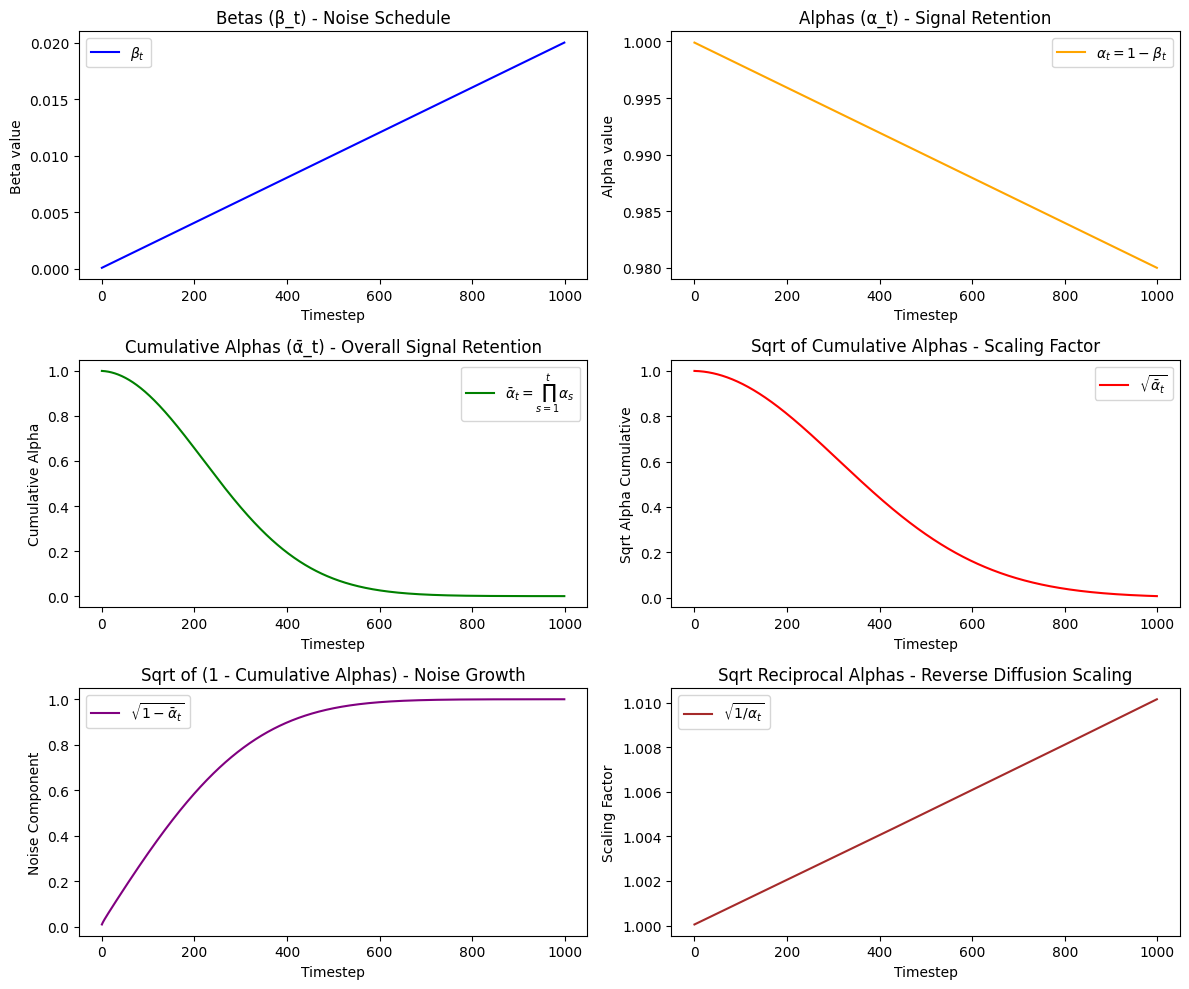

In [ ]:
import torch
import math
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Function to get the beta schedule
def get_beta_schedule(schedule_type, n_timesteps):
    if schedule_type == "linear":
        return torch.linspace(0.0001, 0.02, n_timesteps)
    elif schedule_type == "cosine":
        steps = n_timesteps + 1
        x = torch.linspace(0, n_timesteps, steps)
        alphas_cumprod = torch.cos(((x / n_timesteps) + 0.008) / 1.008 * math.pi * 0.5) ** 2
        alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
        betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
        return torch.clip(betas, 0.0001, 0.9999)
    else:
        raise NotImplementedError(f"Unknown beta schedule: {schedule_type}")

# Function to compute all necessary diffusion parameters
def setup_diffusion_parameters(n_timesteps, schedule_type="linear", device='cpu'):
    betas = get_beta_schedule(schedule_type, n_timesteps).to(device)
    alphas = (1 - betas).to(device)
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
    sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
    sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)
    sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

    return {
        'betas': betas,
        'alphas': alphas,
        'alphas_cumprod': alphas_cumprod,
        'alphas_cumprod_prev': alphas_cumprod_prev,
        'sqrt_alphas_cumprod': sqrt_alphas_cumprod,
        'sqrt_one_minus_alphas_cumprod': sqrt_one_minus_alphas_cumprod,
        'sqrt_recip_alphas': sqrt_recip_alphas
    }

# Number of timesteps
n_timesteps = 1000
params = setup_diffusion_parameters(n_timesteps, schedule_type="linear")

# Convert parameters to numpy for plotting
timesteps = torch.arange(n_timesteps).cpu().numpy()
betas = params['betas'].cpu().numpy()
alphas = params['alphas'].cpu().numpy()
alphas_cumprod = params['alphas_cumprod'].cpu().numpy()
sqrt_alphas_cumprod = params['sqrt_alphas_cumprod'].cpu().numpy()
sqrt_one_minus_alphas_cumprod = params['sqrt_one_minus_alphas_cumprod'].cpu().numpy()
sqrt_recip_alphas = params['sqrt_recip_alphas'].cpu().numpy()

# Plot all parameters
fig, axes = plt.subplots(3, 2, figsize=(12, 10))

# Plot Betas
axes[0, 0].plot(timesteps, betas, label=r'$\beta_t$', color='blue')
axes[0, 0].set_title("Betas (\u03B2_t) - Noise Schedule")
axes[0, 0].set_xlabel("Timestep")
axes[0, 0].set_ylabel("Beta value")
axes[0, 0].legend()

# Plot Alphas
axes[0, 1].plot(timesteps, alphas, label=r'$\alpha_t = 1 - \beta_t$', color='orange')
axes[0, 1].set_title("Alphas (\u03B1_t) - Signal Retention")
axes[0, 1].set_xlabel("Timestep")
axes[0, 1].set_ylabel("Alpha value")
axes[0, 1].legend()

# Plot Cumulative Alphas
axes[1, 0].plot(timesteps, alphas_cumprod, label=r'$\bar{\alpha}_t = \prod_{s=1}^{t} \alpha_s$', color='green')
axes[1, 0].set_title("Cumulative Alphas (\u03B1̄_t) - Overall Signal Retention")
axes[1, 0].set_xlabel("Timestep")
axes[1, 0].set_ylabel("Cumulative Alpha")
axes[1, 0].legend()

# Plot Sqrt of Cumulative Alphas
axes[1, 1].plot(timesteps, sqrt_alphas_cumprod, label=r'$\sqrt{\bar{\alpha}_t}$', color='red')
axes[1, 1].set_title("Sqrt of Cumulative Alphas - Scaling Factor")
axes[1, 1].set_xlabel("Timestep")
axes[1, 1].set_ylabel("Sqrt Alpha Cumulative")
axes[1, 1].legend()

# Plot Sqrt of (1 - Cumulative Alphas)
axes[2, 0].plot(timesteps, sqrt_one_minus_alphas_cumprod, label=r'$\sqrt{1 - \bar{\alpha}_t}$', color='purple')
axes[2, 0].set_title("Sqrt of (1 - Cumulative Alphas) - Noise Growth")
axes[2, 0].set_xlabel("Timestep")
axes[2, 0].set_ylabel("Noise Component")
axes[2, 0].legend()

# Plot Sqrt Reciprocal Alphas
axes[2, 1].plot(timesteps, sqrt_recip_alphas, label=r'$\sqrt{1/\alpha_t}$', color='brown')
axes[2, 1].set_title("Sqrt Reciprocal Alphas - Reverse Diffusion Scaling")
axes[2, 1].set_xlabel("Timestep")
axes[2, 1].set_ylabel("Scaling Factor")
axes[2, 1].legend()

plt.tight_layout()
plt.show()
